# Initial Setup and Data Preparation:

## Setting up environment

Introduce the dependency so that the user can setup in advance

In [1]:
!git clone https://github.com/Kangningthu/DeepDenoisingGuide

## Setting the file root folder path

In [2]:
import os
import sys

file_root_path = '/content/DeepDenoisingGuide'
sys.path.append(file_root_path)

In [3]:
path_to_image_data = file_root_path + '/natural_images_data/data/Train400'

In [4]:
noise_scale = noise_std = 0.17 # 20 -40/ 255

In [5]:
import os

path_to_saved_models = file_root_path + '/saved_models_natural_image/'
if not os.path.exists(path_to_saved_models):
    os.mkdir(path_to_saved_models)

In [6]:
import os

from PIL import Image

import numpy as np
from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt

import cv2
# from skimage.measure.simple_metrics import compare_psnr
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
import glob
import pickle

import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import argparse
import sys
import torchvision
import torch
from torch.serialization import default_restore_location
from torch.distributions import Poisson
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
sys.path.append(file_root_path + '/electron-microscopy-denoising')
import data
import models
import utils

In [7]:
device = torch.device('cpu')

In [8]:
kernel_size = 2
# noise_std_array = [float(10)/255, float(25)/255, float(55)/255];

n_examples = 3 #number of examples to plot

## Creating Dataloader

n_val random images are set for validation while rest of the images are in training

In [9]:
n_val = 25;
files_source = glob.glob(os.path.join(path_to_image_data, '*.png'))
files_source = np.sort(files_source)
list_val_images = files_source[-n_val:]
list_train_images = list( set(files_source) - set(list_val_images));

In [11]:
import numpy as np
import torch
import cv2
import torch.utils.data as udata
from random import randint


class ImageDataset(udata.Dataset):
	def __init__(self,  list_of_image_path, resize_to_256 = False):
		super(ImageDataset, self).__init__()

		self.n_data = len(list_of_image_path)

		self.data_list = [None]*self.n_data;
		for i in range(self.n_data):

			f = list_of_image_path[i];
			Img = cv2.imread(f)
			Img = self.normalize(np.float32(Img[:,:,0]))
			if resize_to_256:
			    Img = cv2.resize(Img, (256, 256)) 
			self.data_list[i] = Img;

	def __len__(self):
		return self.n_data

	def __getitem__(self, index):
		data = self.data_list[index]
		return torch.Tensor(data).unsqueeze(0);

	def normalize(self, data):
		return data/255.

In [12]:
train_dataset = ImageDataset(list_train_images,
                                         resize_to_256 = True)
val_dataset = ImageDataset(list_val_images,
                                       resize_to_256 = True)

train_loader = DataLoader(dataset=train_dataset,
                          num_workers=0,
                          batch_size=4, shuffle=True);

val_loader = DataLoader(dataset = val_dataset,
                       num_workers = 0,
                       batch_size = 4,
                       shuffle = True)

In [13]:
train_dataset = train_loader.dataset
val_dataset = val_loader.dataset
test_loader = val_loader
test_dataset = test_loader.dataset

In [14]:
train_loader.batch_size

4

In [15]:
len(train_dataset)

375

In [16]:
len(test_dataset)

25

In [17]:
# val_dataset[1]['image'].size()

In [18]:
# test_dataset[1]['image'].size()

In [19]:
def batch_PSNR(img, imclean, data_range):
    Img = img.data.cpu().numpy().astype(np.float32)
    Iclean = imclean.data.cpu().numpy().astype(np.float32)
    PSNR = 0
    for i in range(Img.shape[0]):
        PSNR += compare_psnr(Iclean[i,:,:,:], Img[i,:,:,:], data_range=data_range)
    return (PSNR/Img.shape[0])

In [20]:
def normalize(data):
    return data/255.

def get_test_image(path_to_dataset, index):
    files_source = glob.glob(os.path.join(path_to_dataset, '*.png'))
    files_source.sort()

    f = files_source[index];

    Img = cv2.imread(f)
    Img = normalize(np.float32(Img[:,:,0]))
    Img = np.expand_dims(Img, 0)
    Img = np.expand_dims(Img, 1)
    ISource = torch.Tensor(Img).to(device)

    return ISource


In [21]:
def tensor_to_image(torch_image, low=0.0, high = 1.0, clamp = True):
    if clamp:
        torch_image = torch.clamp(torch_image, low, high);
    return torch_image[0,0].cpu().data.numpy()

In [22]:


def get_noise(data, noise_std = 0.1, mode='poisson', max_noise = 5e-1, noise_scale=50):

    noise = get_noise_others(data, noise_std, mode, max_noise)
    return noise

def get_noise_others(data, noise_std = 0.1, mode='S', max_noise = 5e-1):
    noise = torch.randn_like(data);
    if mode == 'B':
        n = noise.shape[0];
        noise_tensor_array = max_noise * torch.rand(n);
        for i in range(n):
            noise.data[i] = noise.data[i] * noise_tensor_array[i];
    else:
        noise.data = noise.data * noise_std;
    return noise

In [23]:
from torch.distributions import Poisson
import matplotlib.pyplot as plt
# Assume tensor_to_image, plot_2d_log_fft, and batch_PSNR are defined elsewhere

def visualize_denoising(source, net, noise_std=0.1, noise_sample=None, noise_scale=1.0, figsize=(20, 20)):
    fig, axes = plt.subplots(1, 3, sharex=True, sharey='row', figsize=figsize)
    print(source)

    axes[0].imshow(tensor_to_image(source), cmap='gray')
    print(tensor_to_image(source))
    axes[0].axis('off')

    print(source[0, 0].size())

    if noise_sample is None:
        noisy  = source + get_noise(source, noise_std=noise_std,noise_scale = noise_scale)

    axes[1].imshow(tensor_to_image(noisy), cmap='gray')
    axes[1].axis('off')
    axes[1].set_title(str(batch_PSNR(noisy, source, 1.0)))

    denoised = net(noisy)

    axes[2].imshow(tensor_to_image(denoised), cmap='gray')
    axes[2].axis('off')
    axes[2].set_title(str(batch_PSNR(torch.clamp(denoised, 0.0, 1.0), source, 1.0)))

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

# Note: The function now accepts an additional parameter 'noise_scale'
# You can adjust 'noise_scale' to control the level of noise.


In [24]:
val_dataset[0]

tensor([[[0.7255, 0.7342, 0.7584,  ..., 0.3830, 0.6108, 0.8000],
         [0.7820, 0.7956, 0.8242,  ..., 0.3128, 0.4327, 0.5303],
         [0.8325, 0.8460, 0.8750,  ..., 0.2142, 0.2832, 0.3693],
         ...,
         [0.6829, 0.6599, 0.6425,  ..., 0.2585, 0.2504, 0.2384],
         [0.6911, 0.6756, 0.6667,  ..., 0.2457, 0.2384, 0.2314],
         [0.6824, 0.6693, 0.6679,  ..., 0.2403, 0.2335, 0.2314]]])

In [25]:
train_dataset[0].size()

torch.Size([1, 256, 256])

In [26]:
# noise_scale = noise_std = 1

# Theoretical Wiener Filter

In [27]:
def theoretical_wiener_from_data(train_dataset, fft_shift = True, noise_std=0.1,fft_sample = (256, 256),  n = 10, noise_scale=50):
    mean_coeff = np.fft.fft2(train_dataset[0].numpy()[0], s = fft_sample) * 0;

    for i in range(n):
        for x in train_dataset:
#             print(x)
#             x = x['image']
#             noisy = x + get_noise(x, noise_std=noise_std);
            source = x

            noisy = source+ get_noise(source, mode = 'poisson', noise_std=noise_std, noise_scale=noise_scale);
#             noisy = Poisson(x).sample()
#             print(noisy.size())
            noise_fft = ( np.fft.fft2(noisy.numpy()[0], s = fft_sample) );
            clean_fft = ( np.fft.fft2(x.numpy()[0], s = fft_sample) );

            mean_coeff += clean_fft * np.conjugate(noise_fft) / np.abs(noise_fft+1*10**(-8))**2

    mean_coeff /= n*len(train_dataset)
    if fft_shift:
        return np.fft.fftshift(mean_coeff)
    else:
        return mean_coeff

In [28]:
wiener_star = theoretical_wiener_from_data(train_dataset,noise_std=noise_std,noise_scale=noise_scale)


In [29]:
def validation_error_psnr(model, dataset_val, add_noise = False, noise_mode = 'poisson', noise_std=0.1, max_noise = 5e-1, noise_scale=50):
    model.eval()
    error_val = 0;
    psnr_val = 0;
    total_length = 0;

    criterion = nn.MSELoss(reduction = 'sum');

    for data in dataset_val:
#         data = data['image']
#         data = data.resize((256,256))
        target = data.clone()

        if add_noise:

            data = data + get_noise(data, mode = noise_mode,noise_std=noise_std, max_noise = max_noise, noise_scale=noise_scale)

        data = data.to(device)
        target = target.to(device)
        out_val = model( data );

        error_val += criterion(out_val, target).item()
        psnr_val += ( batch_PSNR(out_val, target, 1.0) * data.shape[0] )
        total_length += data.shape[0];

    return error_val/total_length, psnr_val/total_length

In [30]:
def train_network_on_noise(model, train_loader, val_loader,
                            add_noise = False, noise_mode = 'poisson', max_noise = 5e-1, noise_std = 0.1,
                            max_epoch = 50,  milestone = 50, lr=0.001, plot_loss = True, verbose = False,
                            verbose_freq = 100, early_stopping = True, noise_scale=50):
    model = model.to(device)

    optimizer = optim.Adam( filter(lambda p: p.requires_grad, model.parameters()) , lr=lr);
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience = 5, factor = 0.5)
    criterion = nn.MSELoss()

    train_loss = np.zeros(max_epoch);
    val_loss = np.zeros(max_epoch);

    train_psnr = np.zeros(max_epoch);
    val_psnr = np.zeros(max_epoch);

    best_model = None;
    best_val_loss = np.inf;

    for epoch in range(max_epoch):

#         if epoch > milestone:
#             for param_group in optimizer.param_groups:
#                 param_group["lr"] = lr/10;

        for i, data in enumerate(train_loader):
            optimizer.zero_grad();
            model.train();
#             data = data['image']
            target = data.clone();

            if add_noise:
#                 data = Poisson(data).sample()
                data = data + get_noise(data, mode = noise_mode,noise_std=noise_std, max_noise = max_noise, noise_scale=noise_scale)

            data = data.to(device)
            target = target.to(device)

            out_train = model(data);
            loss = criterion(out_train, target);
            loss.backward()
            optimizer.step()

        train_loss[epoch], train_psnr[epoch] = validation_error_psnr(model, train_loader,
                                                                add_noise = add_noise);
        val_loss[epoch], val_psnr[epoch] = validation_error_psnr(model, val_loader,
                                                            add_noise = add_noise);
        scheduler.step(val_psnr[epoch])

        if (epoch+1) % verbose_freq == 0 and verbose:
            print(epoch+1, 'train error: ', train_loss[epoch],
                             'val error: ', val_loss[epoch],
                              'train psnr: ', train_psnr[epoch],
                             'val psnr: ', val_psnr[epoch]);

        if val_loss[epoch] < best_val_loss:
            best_model = model.state_dict();
            best_val_loss = val_loss[epoch]

    if early_stopping:
        model.load_state_dict(best_model)

    if plot_loss:
        plt.semilogy(np.arange(1, max_epoch+1), train_loss, label = 'train loss');
        plt.semilogy(np.arange(1, max_epoch+1), val_loss, label = 'val loss')
        plt.legend()
        plt.show()

        plt.plot(np.arange(1, max_epoch+1), train_psnr, label = 'train psnr');
        plt.plot(np.arange(1, max_epoch+1), val_psnr, label = 'val psnr')
        plt.legend()
        plt.show()

    return model, train_psnr, val_psnr

# DNN training: DnCNN

It is recommended to skip this process if GPU is not avaible, please load the provided pretrained model

## Setting the device (GPU or CPU)

In [31]:
USE_CUDA = True
device = torch.device("cuda") if (
        torch.cuda.is_available() and USE_CUDA) else torch.device("cpu")

In [32]:
# USE_CUDA = False
# device = torch.device("cuda") if (
#         torch.cuda.is_available() and USE_CUDA) else torch.device("cpu")

## Train supervised model

In [33]:
from utils import *

In [34]:
pretrained_base = file_root_path + '/pretrained_models/Natural_images'


In [35]:
def load_model_from_scratch(checkpoint_path):
    state_dict = torch.load(checkpoint_path, map_location=lambda s, l: default_restore_location(s, "cpu"),weights_only=False)
    args = argparse.Namespace(**{ **vars(state_dict["args"]), "no_log": True})
    print(args)

    model = models.build_model(args).to(device)
#     model.load_state_dict(state_dict["model"][0])
#     model.eval()
    return model

In [36]:
# Choose a model (pre-trained options: 'dncnn', 'unet', 'rcnn', 'sdensenet')
model = 'dncnn'

# Select the range of noise levels (stdev, relative to intensities in range [0,255])
# used during training (options are 0-10, 0-30, 0-55, 0-100).
l = 0   # lower bound of training range
h = 100 # upper bound of training range

BF_CNN = load_model_from_scratch(os.path.join(pretrained_base, model, str(l)+'-'+str(h)+'.pt'))

Namespace(data_path='../data/', dataset='bsd400', batch_size=128, model='dncnn', noise_mode='B', noise_std=25, min_noise=100, max_noise=0, lr=0.001, num_epochs=70, valid_interval=1, save_interval=1, seed=0, output_dir='experiments', experiment=None, resume_training=False, restore_file=None, no_save=False, step_checkpoints=False, no_log=True, log_interval=100, no_visual=False, visual_interval=100, no_progress=False, draft=False, dry_run=False, in_channels=1, hidden_size=64, num_layers=20, bias=False, experiment_dir=None, checkpoint_dir=None, log_dir=None, log_file=None)


In [37]:

def get_noise(data, noise_std = 0.1, mode='poisson', max_noise = 5e-1, noise_scale=50):

    noise = get_noise_others(data, noise_std, mode, max_noise)
    return noise

def get_noise_others(data, noise_std = 0.1, mode='S', max_noise = 5e-1):
    noise = torch.randn_like(data);
    if mode == 'B':
        n = noise.shape[0];
        noise_tensor_array = max_noise * torch.rand(n);
        for i in range(n):
            noise.data[i] = noise.data[i] * noise_tensor_array[i];
    else:
        noise.data = noise.data * noise_std;
    return noise

In [38]:
def validation_error_psnr(model, dataset_val, add_noise = False, noise_mode = 'poisson', noise_std=0.1, max_noise = 5e-1, noise_scale=50):
    model.eval()
    error_val = 0;
    psnr_val = 0;
    total_length = 0;

    criterion = nn.MSELoss(reduction = 'mean');

    for data in dataset_val:
#         data = data['image']
#         data = data.resize((256,256))
        target = data.clone()

        if add_noise:

            data = data + get_noise(data, mode = noise_mode,noise_std=noise_std, max_noise = max_noise, noise_scale=noise_scale)

        data = data.to(device)
        target = target.to(device)
        out_val = model( data );

        error_val += criterion(out_val, target).item()
        psnr_val += ( batch_PSNR(out_val, target, 1.0) * data.shape[0] )
        total_length += data.shape[0];

    return error_val/total_length, psnr_val/total_length

In [39]:
def train_network_on_noise_supervised(model, train_loader, val_loader,
                            add_noise = False, noise_mode = 'poisson', max_noise = 5e-1, noise_std = 0.1,
                            max_epoch = 50,  milestone = 50, lr=0.001, plot_loss = True, verbose = False,
                            verbose_freq = 100, early_stopping = True, noise_scale=50):
    model = model.to(device)

    optimizer = optim.Adam( filter(lambda p: p.requires_grad, model.parameters()) , lr=lr);
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience = 5, factor = 0.5)
    criterion = nn.MSELoss()

    train_loss = np.zeros(max_epoch);
    val_loss = np.zeros(max_epoch);

    train_psnr = np.zeros(max_epoch);
    val_psnr = np.zeros(max_epoch);

    best_model = None;
    best_val_loss = np.inf;

    for epoch in range(max_epoch):

#         if epoch > milestone:
#             for param_group in optimizer.param_groups:
#                 param_group["lr"] = lr/10;

        for i, data in enumerate(train_loader):
            optimizer.zero_grad();
            model.train();
#             data = data['image']
            target = data.clone();

            if add_noise:
#                 data = Poisson(data).sample()
                data = data + get_noise(data, mode = noise_mode,noise_std=noise_std, max_noise = max_noise, noise_scale=noise_scale)
#                 target = target +  get_noise(data, mode = noise_mode,noise_std=noise_std, max_noise = max_noise, noise_scale=noise_scale)

            data = data.to(device)
            target = target.to(device)

            out_train = model(data);
            loss = criterion(out_train, target);
            loss.backward()
            optimizer.step()

        train_loss[epoch], train_psnr[epoch] = validation_error_psnr(model, train_loader,
                                                                add_noise = add_noise);
        val_loss[epoch], val_psnr[epoch] = validation_error_psnr(model, val_loader,
                                                            add_noise = add_noise);
        scheduler.step(val_psnr[epoch])

        if (epoch+1) % verbose_freq == 0 and verbose:
            print(epoch+1, 'train error: ', train_loss[epoch],
                             'val error: ', val_loss[epoch],
                              'train psnr: ', train_psnr[epoch],
                             'val psnr: ', val_psnr[epoch]);

        if val_loss[epoch] < best_val_loss:
            best_model = model.state_dict();
            best_val_loss = val_loss[epoch]

    if early_stopping:
        model.load_state_dict(best_model)

    if plot_loss:
        plt.semilogy(np.arange(1, max_epoch+1), train_loss, label = 'train loss');
        plt.semilogy(np.arange(1, max_epoch+1), val_loss, label = 'val loss')
        plt.legend()
        plt.show()

        plt.plot(np.arange(1, max_epoch+1), train_psnr, label = 'train psnr');
        plt.plot(np.arange(1, max_epoch+1), val_psnr, label = 'val psnr')
        plt.legend()
        plt.show()

    return model, train_psnr, val_psnr, train_loss, val_loss

In [40]:
def train_network_on_noise_supervised_fixed(model, train_loader, val_loader,
                            add_noise = False, noise_mode = 'poisson', max_noise = 5e-1, noise_std = 0.1,
                            max_epoch = 50,  milestone = 50, lr=0.001, plot_loss = True, verbose = False,
                            verbose_freq = 100, early_stopping = True, noise_scale=50):
    model = model.to(device)

    optimizer = optim.Adam( filter(lambda p: p.requires_grad, model.parameters()) , lr=lr);
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience = 5, factor = 0.5)
    criterion = nn.MSELoss()

    train_loss = np.zeros(max_epoch);
    val_loss = np.zeros(max_epoch);

    train_psnr = np.zeros(max_epoch);
    val_psnr = np.zeros(max_epoch);

    best_model = None;
    best_val_loss = np.inf;


    noise_list = []

    for i, data in enumerate(train_loader):

        noise_list.append(get_noise(data, mode = noise_mode,noise_std=noise_std, max_noise = max_noise, noise_scale=noise_scale))





    for epoch in range(max_epoch):

#         if epoch > milestone:
#             for param_group in optimizer.param_groups:
#                 param_group["lr"] = lr/10;

        for i, data in enumerate(train_loader):
            optimizer.zero_grad();
            model.train();
#             data = data['image']
            target = data.clone();

            if add_noise:
#                 data = Poisson(data).sample()
                data = data + noise_list[i]
#                 target = target +  get_noise(data, mode = noise_mode,noise_std=noise_std, max_noise = max_noise, noise_scale=noise_scale)

            data = data.to(device)
            target = target.to(device)

            out_train = model(data);
            loss = criterion(out_train, target);
            loss.backward()
            optimizer.step()

        train_loss[epoch], train_psnr[epoch] = validation_error_psnr(model, train_loader,
                                                                add_noise = add_noise);
        val_loss[epoch], val_psnr[epoch] = validation_error_psnr(model, val_loader,
                                                            add_noise = add_noise);
        scheduler.step(val_psnr[epoch])

        if (epoch+1) % verbose_freq == 0 and verbose:
            print(epoch+1, 'train error: ', train_loss[epoch],
                             'val error: ', val_loss[epoch],
                              'train psnr: ', train_psnr[epoch],
                             'val psnr: ', val_psnr[epoch]);

        if val_loss[epoch] < best_val_loss:
            best_model = model.state_dict();
            best_val_loss = val_loss[epoch]

    if early_stopping:
        model.load_state_dict(best_model)

    if plot_loss:
        plt.semilogy(np.arange(1, max_epoch+1), train_loss, label = 'train loss');
        plt.semilogy(np.arange(1, max_epoch+1), val_loss, label = 'val loss')
        plt.legend()
        plt.show()

        plt.plot(np.arange(1, max_epoch+1), train_psnr, label = 'train psnr');
        plt.plot(np.arange(1, max_epoch+1), val_psnr, label = 'val psnr')
        plt.legend()
        plt.show()

    return model, train_psnr, val_psnr, train_loss, val_loss

#### Continuous noise sampling

##### DNCNN

Namespace(data_path='../data/', dataset='bsd400', batch_size=128, model='dncnn', noise_mode='B', noise_std=25, min_noise=100, max_noise=0, lr=0.001, num_epochs=70, valid_interval=1, save_interval=1, seed=0, output_dir='experiments', experiment=None, resume_training=False, restore_file=None, no_save=False, step_checkpoints=False, no_log=True, log_interval=100, no_visual=False, visual_interval=100, no_progress=False, draft=False, dry_run=False, in_channels=1, hidden_size=64, num_layers=20, bias=False, experiment_dir=None, checkpoint_dir=None, log_dir=None, log_file=None)
1 train error:  0.0009909285741547744 val error:  0.0011248370446264744 train psnr:  24.033791117997698 val psnr:  23.971668259887903
2 train error:  0.000360737933156391 val error:  0.0004624537751078606 train psnr:  28.56700768884805 val psnr:  28.16290724110987
3 train error:  0.0003153048052142064 val error:  0.0003882539365440607 train psnr:  29.248031536926515 val psnr:  28.75507593987766
4 train error:  0.00029277

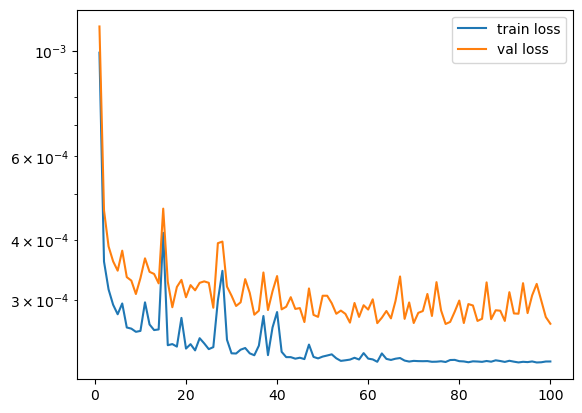

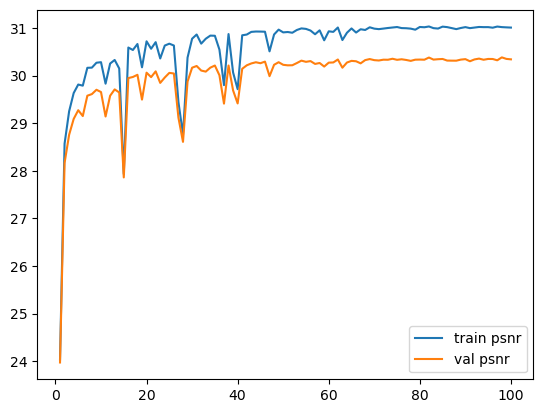

In [41]:
# Choose a model (pre-trained options: 'dncnn', 'unet', 'rcnn', 'sdensenet')
model = 'dncnn'

l = 0   # lower bound of training range
h = 100 # upper bound of training range

BF_CNN = load_model_from_scratch(os.path.join(file_root_path, 'pretrained_models', 'Natural_images',model, str(l)+'-'+str(h)+'.pt'))

operation_seed_counter = 0
net_supervised_continous = BF_CNN

net_supervised_continous, train_psnr_continous, val_psnr_continous, train_loss_continous, val_loss_continous = train_network_on_noise_supervised(net_supervised_continous, train_loader, val_loader,
                        add_noise = True,
                        noise_mode = 'poisson',
                        max_epoch = 100,
                        milestone = 100,
                        lr = 1e-4,
                        verbose = True,
                        verbose_freq = 1,
                        plot_loss = True)
#             visualize_filters(net_temp)
net_dict_filename = 'natural_image_net_supervised_continous.pth'
torch.save(net_supervised_continous.cpu().state_dict(),os.path.join(path_to_saved_models, net_dict_filename))

##### Unet

In [42]:
sys.path.append(file_root_path + '/electron-microscopy-denoising')
sys.path.append(file_root_path + '/electron-microscopy-denoising/models_microscopy')

import models_microscopy

In [43]:
diff_checkpoint_path = {
    'White-4-128': file_root_path + '/electron-microscopy-denoising/checkpoints/unet-128-small.pt',
    # 'White-6-128': file_root_path + '/electron-microscopy-denoising/checkpoints/unet-128-big.pt',
}

In [44]:
def load_unet_model_fromscratch(checkpoint_path):
    state_dict = torch.load( checkpoint_path, map_location=lambda s,
                                l: default_restore_location(s,"cpu"), weights_only=False)

    args = argparse.Namespace(
        **{**vars(state_dict["args"])})
    model = models_microscopy.build_model(args).to(device)
#     model.load_state_dict(state_dict["model"][0])
#     model.eval()
    return model

In [45]:
net_supervised_continous_unet = load_unet_model_fromscratch(file_root_path + '/electron-microscopy-denoising/checkpoints/unet-128-small.pt').to(device)

1 train error:  0.0018097017121811707 val error:  0.0018397690076380967 train psnr:  23.123905539157356 val psnr:  22.899282205750882


2 train error:  0.0010006567450861136 val error:  0.0012052521854639053 train psnr:  24.193134551087176 val psnr:  23.988398440152128
3 train error:  0.0009726844889422258 val error:  0.0010227345023304225 train psnr:  24.839248983507392 val psnr:  24.7481676526291
4 train error:  0.0005875726913412412 val error:  0.0006518647586926818 train psnr:  26.636064355487473 val psnr:  26.380249522426013
5 train error:  0.0008608258285870155 val error:  0.0010132692940533162 train psnr:  25.10886964956639 val psnr:  24.971320722715994
6 train error:  0.0004998750087494651 val error:  0.0006730911927297712 train psnr:  27.31898351256288 val psnr:  26.921988516828588
7 train error:  0.00048741590324789287 val error:  0.000554606057703495 train psnr:  27.784371202708023 val psnr:  27.379024822243213
8 train error:  0.00044891779279957215 val error:  0.0006080539524555206 train psnr:  27.73477484505531 val psnr:  27.21852383718729
9 train error:  0.00047177396280070145 val error:  0.00061033371835

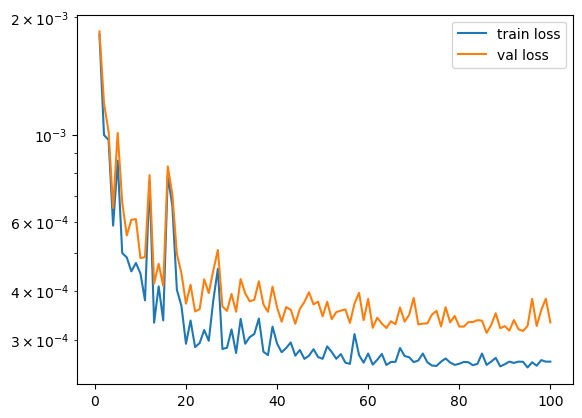

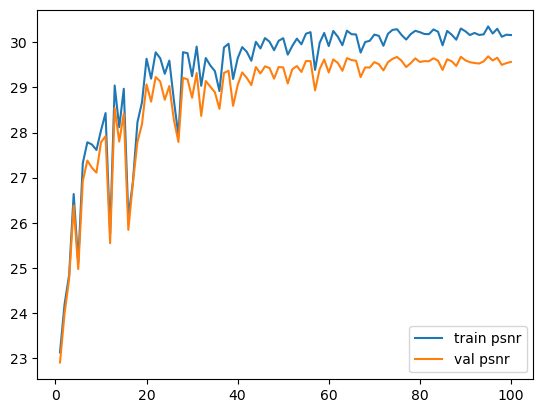

In [46]:





operation_seed_counter = 0


net_supervised_continous_unet, train_psnr_continous_unet, val_psnr_continous_unet, train_loss_continous_unet, val_loss_continous_unet = train_network_on_noise_supervised(net_supervised_continous_unet, train_loader, val_loader,
                        add_noise = True,
                        noise_mode = 'poisson',
                        max_epoch = 100,
                        milestone = 100,
                        lr = 1e-4,
                        verbose = True,
                        verbose_freq = 1,
                        plot_loss = True)
#             visualize_filters(net_temp)
net_dict_filename = 'natural_image_net_supervised_continous_unet.pth'
torch.save(net_supervised_continous_unet.cpu().state_dict(),os.path.join(path_to_saved_models, net_dict_filename))

#### Fixed noise

Namespace(data_path='../data/', dataset='bsd400', batch_size=128, model='dncnn', noise_mode='B', noise_std=25, min_noise=100, max_noise=0, lr=0.001, num_epochs=70, valid_interval=1, save_interval=1, seed=0, output_dir='experiments', experiment=None, resume_training=False, restore_file=None, no_save=False, step_checkpoints=False, no_log=True, log_interval=100, no_visual=False, visual_interval=100, no_progress=False, draft=False, dry_run=False, in_channels=1, hidden_size=64, num_layers=20, bias=False, experiment_dir=None, checkpoint_dir=None, log_dir=None, log_file=None)
1 train error:  0.0009488213323056698 val error:  0.0010741996113210917 train psnr:  24.223610828604073 val psnr:  24.144002367167136


2 train error:  0.0003811042246719201 val error:  0.000476588262245059 train psnr:  28.273859029923756 val psnr:  27.963280780383403
3 train error:  0.00030662612927456696 val error:  0.00037475758232176305 train psnr:  29.369955738362915 val psnr:  28.858247155961266
4 train error:  0.0003294483125209808 val error:  0.0003846132243052125 train psnr:  28.951755681262767 val psnr:  28.615459099536498
5 train error:  0.0003410479401548703 val error:  0.0003980270866304636 train psnr:  28.78661391957293 val psnr:  28.551223521778297
6 train error:  0.00029544160856554905 val error:  0.00037292908411473035 train psnr:  29.707130346107437 val psnr:  29.116349480253998
7 train error:  0.00028206391011675197 val error:  0.00033304727170616386 train psnr:  29.715770439778193 val psnr:  29.289861597629532
8 train error:  0.00027312944394846755 val error:  0.0003374224482104182 train psnr:  29.891088072755625 val psnr:  29.401204916114487
9 train error:  0.00026458043574045104 val error:  0.0003

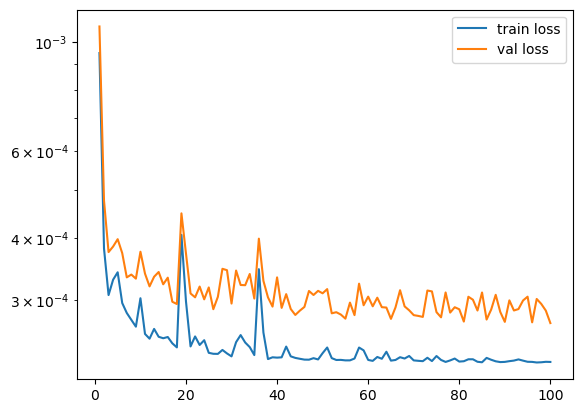

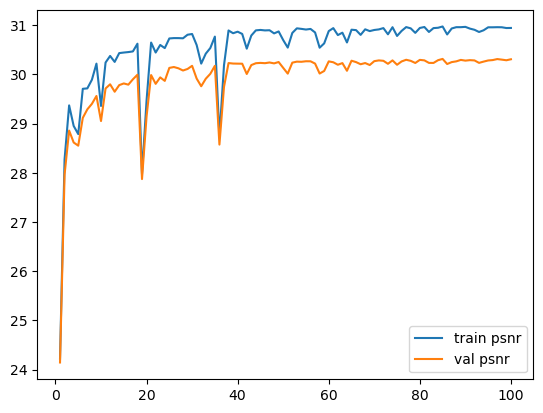

In [47]:

# Choose a model (pre-trained options: 'dncnn', 'unet', 'rcnn', 'sdensenet')
model = 'dncnn'

# Select the range of noise levels (stdev, relative to intensities in range [0,255])
# used during training (options are 0-10, 0-30, 0-55, 0-100).
l = 0   # lower bound of training range
h = 100 # upper bound of training range

BF_CNN = load_model_from_scratch(os.path.join(pretrained_base, model, str(l)+'-'+str(h)+'.pt'))


operation_seed_counter = 0
net_supervised_fixed_noise = BF_CNN

net_supervised_fixed_noise, train_psnr_fixed_noise, val_psnr_fixed_noise, train_loss_fixed_noise, val_loss_fixed_noise = train_network_on_noise_supervised_fixed(net_supervised_fixed_noise, train_loader, val_loader,
                        add_noise = True,
                        noise_mode = 'poisson',
                        max_epoch = 100,
                        milestone = 100,
                        lr = 1e-4,
                        verbose = True,
                        verbose_freq = 1,
                        plot_loss = True)
#             visualize_filters(net_temp)
net_dict_filename = 'natural_image_net_supervised_fixed_noise.pth'
torch.save(net_supervised_fixed_noise.cpu().state_dict(),os.path.join(path_to_saved_models, net_dict_filename))

In [48]:
def moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')


def plot_combined_losses(train_loss, val_loss, train_loss_dnn, val_loss_dnn, save_path='combined_losses.pdf', title1='DNN without Batch Normalization', title2='DNN with Batch Normalization', title='Combined Losses', y_max=0.2, smooth=False, xlim=100, figsize=(8,8), tick_font_size=14, ylabel='MSE'):
    y_min = 0
    y_max = y_max
    fig, ax = plt.subplots(figsize=figsize)

    if smooth:
        # Apply moving average if smoothing is desired
        train_loss = moving_average(train_loss)
        val_loss = moving_average(val_loss)
        train_loss_dnn = moving_average(train_loss_dnn)
        val_loss_dnn = moving_average(val_loss_dnn)

    # Plotting for the first experiment
    ax.plot(train_loss, label=title1 + ': Train ' + ylabel, color='blue')
    ax.plot(val_loss, label=title1 + ': Validation ' + ylabel, color='blue', linestyle='-.')
    # ax.axhline(y=wiener_star_loss, color='red', linestyle='--', label='Wiener Star Loss')

    # Plotting for the DNN experiment
    ax.plot(train_loss_dnn, label=title2 + ': Train ' + ylabel, color='green')
    ax.plot(val_loss_dnn, label=title2 + ': Validation ' + ylabel, color='green', linestyle='-.')

    # ax.set_title(title, fontsize=16)
    ax.set_xlabel('Epoch', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.legend(fontsize=16)
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), fancybox=True, shadow=True, ncol=2)

    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(0, xlim)

    ax.tick_params(axis='both', which='major', labelsize=tick_font_size)


    plt.tight_layout()
    save_path = title1 + title2 + '.png'
    plt.savefig(save_path, dpi=300)
    plt.show()


### Compare training and validation loss

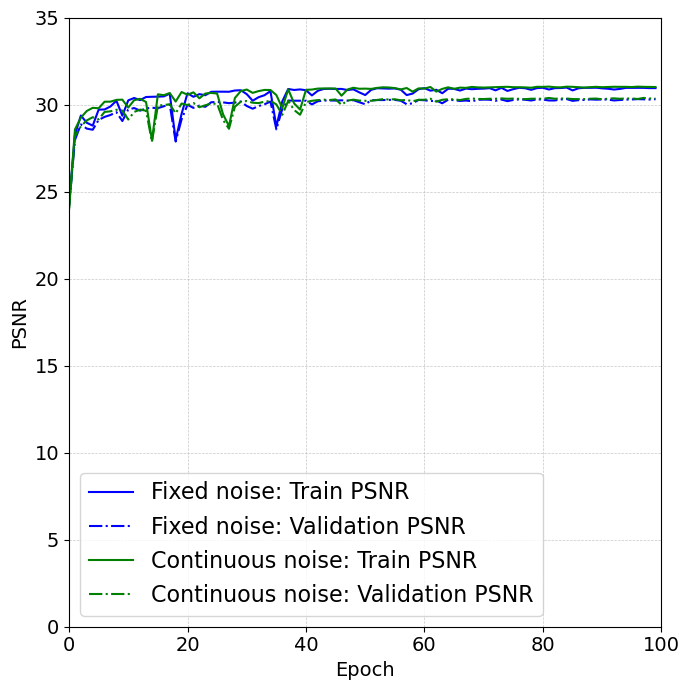

In [49]:
plot_combined_losses(train_psnr_fixed_noise, val_psnr_fixed_noise, train_psnr_continous, val_psnr_continous, title1='Fixed noise', title2='Continuous noise', y_max=35, smooth=False, xlim=100, figsize=(7,7),ylabel='PSNR')

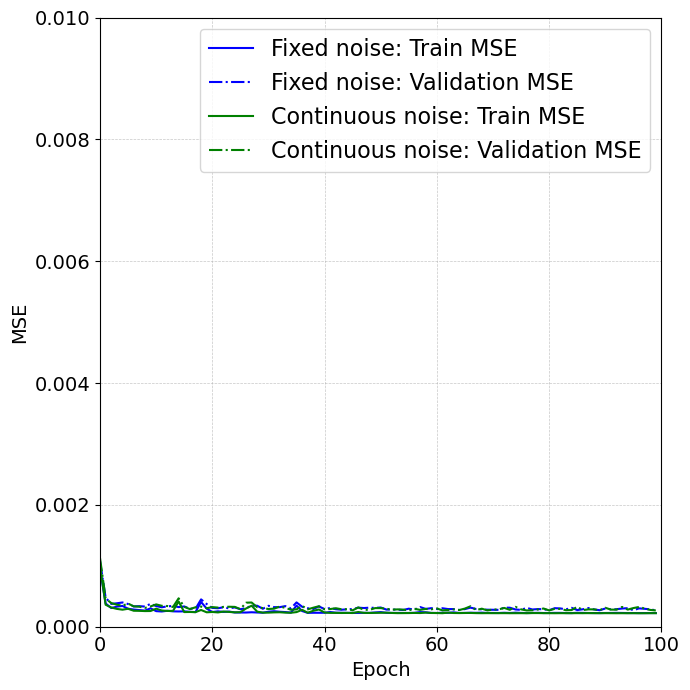

In [50]:
plot_combined_losses(train_loss_fixed_noise, val_loss_fixed_noise, train_loss_continous, val_loss_continous, title1='Fixed noise', title2='Continuous noise', y_max=0.01, smooth=False, xlim=100, figsize=(7,7))

## Train unsupervised model: Noise2Noise

In [51]:
def train_network_on_noise2noise(model, train_loader, val_loader,
                            add_noise = False, noise_mode = 'poisson', max_noise = 5e-1, noise_std = 0.1,
                            max_epoch = 50,  milestone = 50, lr=0.001, plot_loss = True, verbose = False,
                            verbose_freq = 100, early_stopping = True, noise_scale=50):
    model = model.to(device)

    optimizer = optim.Adam( filter(lambda p: p.requires_grad, model.parameters()) , lr=lr);
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience = 5, factor = 0.5)
    criterion = nn.MSELoss()

    train_loss = np.zeros(max_epoch);
    val_loss = np.zeros(max_epoch);

    train_psnr = np.zeros(max_epoch);
    val_psnr = np.zeros(max_epoch);

    best_model = None;
    best_val_loss = np.inf;

    for epoch in range(max_epoch):

#         if epoch > milestone:
#             for param_group in optimizer.param_groups:
#                 param_group["lr"] = lr/10;

        for i, data in enumerate(train_loader):
            optimizer.zero_grad();
            model.train();
#             data = data['image']
            target = data.clone();

            if add_noise:
#                 data = Poisson(data).sample()
                data = data + get_noise(data, mode = noise_mode,noise_std=noise_std, max_noise = max_noise, noise_scale=noise_scale)
                target = target +  get_noise(data, mode = noise_mode,noise_std=noise_std, max_noise = max_noise, noise_scale=noise_scale)

            data = data.to(device)
            target = target.to(device)

            out_train = model(data);
            loss = criterion(out_train, target);
            loss.backward()
            optimizer.step()

        train_loss[epoch], train_psnr[epoch] = validation_error_psnr(model, train_loader,
                                                                add_noise = add_noise);
        val_loss[epoch], val_psnr[epoch] = validation_error_psnr(model, val_loader,
                                                            add_noise = add_noise);
        scheduler.step(val_psnr[epoch])

        if (epoch+1) % verbose_freq == 0 and verbose:
            print(epoch+1, 'train error: ', train_loss[epoch],
                             'val error: ', val_loss[epoch],
                              'train psnr: ', train_psnr[epoch],
                             'val psnr: ', val_psnr[epoch]);

        if val_loss[epoch] < best_val_loss:
            best_model = model.state_dict();
            best_val_loss = val_loss[epoch]

    if early_stopping:
        model.load_state_dict(best_model)

    if plot_loss:
        plt.semilogy(np.arange(1, max_epoch+1), train_loss, label = 'train loss');
        plt.semilogy(np.arange(1, max_epoch+1), val_loss, label = 'val loss')
        plt.legend()
        plt.show()

        plt.plot(np.arange(1, max_epoch+1), train_psnr, label = 'train psnr');
        plt.plot(np.arange(1, max_epoch+1), val_psnr, label = 'val psnr')
        plt.legend()
        plt.show()

    return model, train_psnr, val_psnr

Namespace(data_path='../data/', dataset='bsd400', batch_size=128, model='dncnn', noise_mode='B', noise_std=25, min_noise=100, max_noise=0, lr=0.001, num_epochs=70, valid_interval=1, save_interval=1, seed=0, output_dir='experiments', experiment=None, resume_training=False, restore_file=None, no_save=False, step_checkpoints=False, no_log=True, log_interval=100, no_visual=False, visual_interval=100, no_progress=False, draft=False, dry_run=False, in_channels=1, hidden_size=64, num_layers=20, bias=False, experiment_dir=None, checkpoint_dir=None, log_dir=None, log_file=None)


1 train error:  0.0009578857067972422 val error:  0.0010911897476762534 train psnr:  24.183779483589916 val psnr:  24.085542067135137
2 train error:  0.0003660596602906783 val error:  0.00048528978135436773 train psnr:  28.581383028341715 val psnr:  28.09654369578549
3 train error:  0.00032325532706454395 val error:  0.0003871173970401287 train psnr:  29.117442277659563 val psnr:  28.65486325185292
4 train error:  0.0003101933247720202 val error:  0.0003815248003229499 train psnr:  29.28894737686 val psnr:  28.847991193668225
5 train error:  0.0002870814081591864 val error:  0.00035732304211705924 train psnr:  29.76081829988159 val psnr:  29.1727147014186
6 train error:  0.0002821106583190461 val error:  0.00034647108521312475 train psnr:  29.750031556434603 val psnr:  29.230535890755668
7 train error:  0.00026943406648933886 val error:  0.0003346478845924139 train psnr:  29.984018316550756 val psnr:  29.44912878240835
8 train error:  0.0003024611305445433 val error:  0.000423599258065

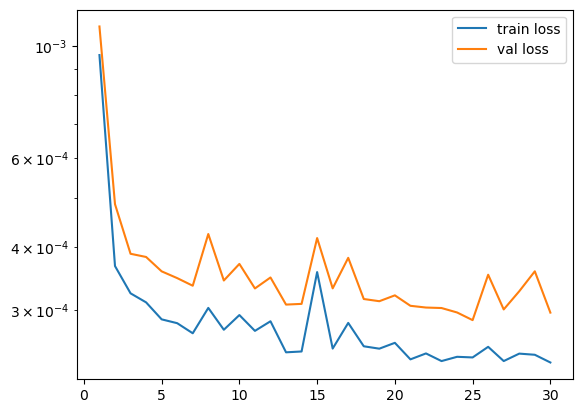

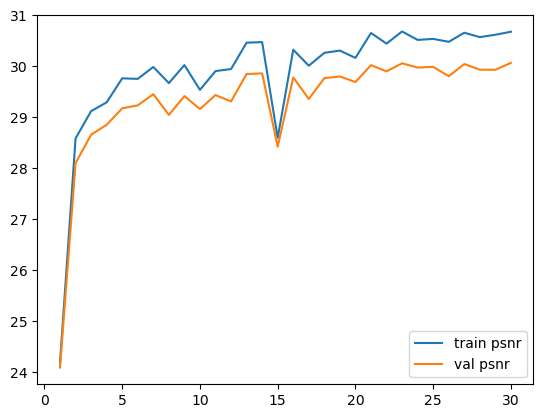

In [52]:



model = 'dncnn'

# Select the range of noise levels (stdev, relative to intensities in range [0,255])
# used during training (options are 0-10, 0-30, 0-55, 0-100).
l = 0   # lower bound of training range
h = 100 # upper bound of training range

BF_CNN = load_model_from_scratch(os.path.join(pretrained_base, model, str(l)+'-'+str(h)+'.pt'))


# operation_seed_counter = 0
net_noise2noise = BF_CNN

net_noise2noise, train_psnr_noise2noise, val_psnr_noise2noise = train_network_on_noise2noise(net_noise2noise, train_loader, val_loader,
                        add_noise = True,
                        noise_mode = 'poisson',
                        max_epoch = 30,
                        milestone = 100,
                        lr = 1e-4,
                        verbose = True,
                        verbose_freq = 1,
                        plot_loss = True)
#             visualize_filters(net_temp)



# validation_dict[kernel_size] = val_psnr_tmpt
plt.show()
print('='*50)

net_dict_filename = 'natural_image_noise2noise.pth'

torch.save(net_noise2noise.cpu().state_dict(),  os.path.join(path_to_saved_models, net_dict_filename))



